# Customer Segmentation - Amazing International Airlines (AIAI)

**Group 68** | Data Mining Assignment - Delivery 2 | December 2025

This notebook implements and evaluates clustering algorithms to identify distinct customer segments within AIAI's loyalty program based on the exploratory analysis performed in Delivery 1.

## 1. Data Preparation & Feature Selection

Loading the cleaned dataset from Delivery 1 and selecting features for clustering based on segmentation relevance.

In [15]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

In [16]:
# Load the cleaned dataset from Delivery 1
df = pd.read_csv('Data/DM_AIAI_FinalCustomerSegments.csv')
# df = df.sample(n=50000, random_state=42)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique customers: {df['Loyalty#'].nunique():,}")

Dataset loaded: 602,532 rows × 40 columns
Unique customers: 16,737


In [17]:
# Select features for clustering based on Delivery 1 analysis

clustering_features = [
    'Customer Lifetime Value',      # Primary value indicator
    'NumFlights',                    # Activity level
    'DistanceKM',                    # Travel intensity
    'PointsAccumulated',             # Loyalty engagement
    'avg_km_per_flight',             # Travel pattern (short vs long haul)
    'avg_points_per_flight',         # Reward efficiency
    'companion_ratio',               # Social travel behavior
    'clv_per_flight',                # Value efficiency
    'months_since_flight',           # Recency
    'active_days'                    # Tenure
]

# Check if all features exist
available_features = [f for f in clustering_features if f in df.columns]
missing_features = [f for f in clustering_features if f not in df.columns]

# Create clustering dataset
df_clustering = df[available_features].copy()

print(f"Shape: {df_clustering.shape}")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

Shape: (602532, 10)
  1. Customer Lifetime Value
  2. NumFlights
  3. DistanceKM
  4. PointsAccumulated
  5. avg_km_per_flight
  6. avg_points_per_flight
  7. companion_ratio
  8. clv_per_flight
  9. months_since_flight
  10. active_days


## 2. Data Scaling & Normalization

Applying robust scaling to handle outliers identified in Delivery 1 EDA.

In [18]:
# Apply RobustScaler (better for data with outliers)
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns, index=df_clustering.index)

display(df_scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,602532.0,4.453291e-01,1.383295,-0.782737,-0.362789,0.0,0.637211,15.634932
NumFlights,602532.0,4.171385e-01,0.723518,-0.142857,-0.142857,0.0,0.857143,2.857143
DistanceKM,602532.0,4.578770e-01,0.667896,-0.059803,-0.059803,0.0,0.940197,2.675929
PointsAccumulated,602532.0,4.579233e-01,0.667980,-0.059782,-0.059782,0.0,0.940218,2.676622
avg_km_per_flight,602532.0,7.024677e-01,1.493814,-0.060891,-0.060891,0.0,0.939109,22.035672
avg_points_per_flight,602532.0,7.026728e-01,1.493744,-0.060606,-0.060606,0.0,0.939394,22.033058
companion_ratio,602532.0,1.138084e+00,2.183334,0.000000,0.000000,0.0,1.000000,8.250000
clv_per_flight,602532.0,3.783464e-01,1.165272,-0.495529,-0.364476,0.0,0.635524,15.462677
months_since_flight,602532.0,1.152728e-18,0.593617,-1.000000,-0.500000,0.0,0.500000,1.000000
active_days,602532.0,-5.671101e-02,0.723786,-2.972659,-0.472317,0.0,0.527683,1.025290


## 3. K-Means Clustering Implementation

**Applying K-Means clustering with 4 clusters, based on the findings from delivery 1**:

**Anticipated Customer Clusters**:

1. **Premium Frequent Flyers**: High CLV, frequent long-haul flights, Aurora tier, high points accumulation
   - Characteristics: Business travelers, high income, low redemption ratio (savers)
   
2. **Value-Conscious Regulars**: Moderate flight frequency, balanced redemption behavior, Nova/Star tiers
   - Characteristics: Mix of business and leisure, price-sensitive, companion flights
   
3. **Aspirational Travelers**: Lower flight count but high CLV-to-salary ratio, point redeemers
   - Characteristics: Leisure-focused, maximize point value, seasonal patterns
   
4. **Dormant/At-Risk**: Low recent activity, varying historical engagement
   - Characteristics: Inactive >12 months, potential churn candidates, reactivation targets

In [ ]:
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

print(f"=== K-MEANS CLUSTERING (k={optimal_k}) ===")
print(f"\nCluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Calculate clustering metrics
sil_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
db_score = davies_bouldin_score(df_scaled, df['KMeans_Cluster'])
ch_score = calinski_harabasz_score(df_scaled, df['KMeans_Cluster'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

=== K-MEANS CLUSTERING (k=4) ===

Cluster Distribution:
KMeans_Cluster
0    417409
1     23512
2    113709
3     47902
Name: count, dtype: int64


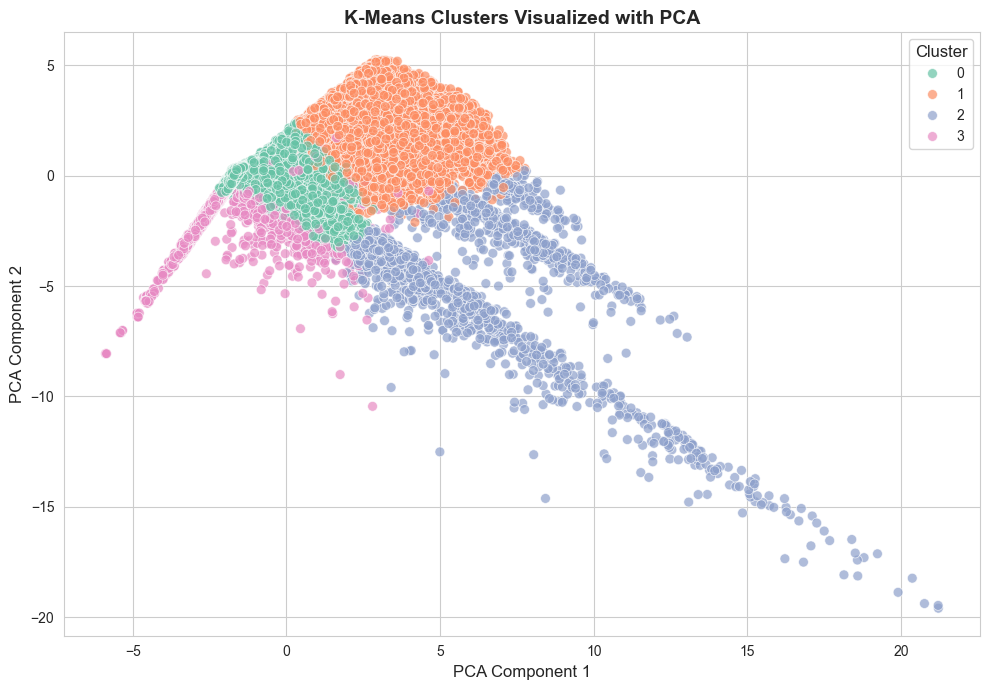

In [ ]:
# Plot K-Means Clusters using PCA for 2D visualization

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'], index=df.index)
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set2', s=50, alpha=0.7)
plt.title('K-Means Clusters Visualized with PCA', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12)
plt.tight_layout()
# plt.savefig(f'{output_dir}/kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Optimal Number of Clusters Determination

Testing different numbers of clusters to find the optimal k using Silhouette Analysis and Dendrogram.

Computing optimal k using 10,000 randomly sampled points...
  k=2 completed
  k=3 completed
  k=4 completed
  k=5 completed
  k=6 completed
  k=7 completed
  k=8 completed
  k=9 completed
  k=10 completed


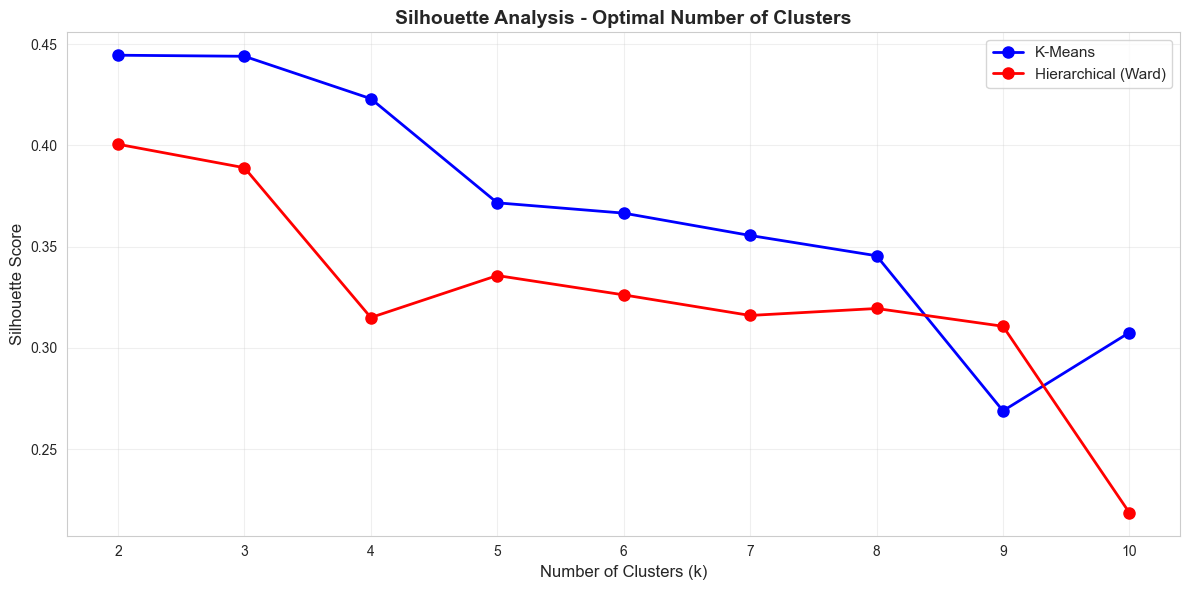


=== SILHOUETTE SCORES BY NUMBER OF CLUSTERS ===

K-Means:
  k=2: 0.4445
  k=3: 0.4440
  k=4: 0.4231
  k=5: 0.3716
  k=6: 0.3665
  k=7: 0.3555
  k=8: 0.3455
  k=9: 0.2689
  k=10: 0.3076

Hierarchical (Ward):
  k=2: 0.4006
  k=3: 0.3890
  k=4: 0.3150
  k=5: 0.3357
  k=6: 0.3261
  k=7: 0.3160
  k=8: 0.3194
  k=9: 0.3106
  k=10: 0.2185

=== OPTIMAL NUMBER OF CLUSTERS ===
K-Means: k=2 (Silhouette: 0.4445)
Hierarchical: k=2 (Silhouette: 0.4006)


In [ ]:
# Silhouette Analysis - Test different numbers of clusters for both algorithms
# Using a random subsample for faster computation
sample_size_optimal = min(10000, len(df_scaled))
sample_indices_optimal = np.random.RandomState(42).choice(len(df_scaled), size=sample_size_optimal, replace=False)
df_scaled_sample = df_scaled.iloc[sample_indices_optimal]

k_range = range(2, 11)
kmeans_silhouette = []
hierarchical_silhouette = []

print(f"Computing optimal k using {sample_size_optimal:,} randomly sampled points...")

for k in k_range:
    # K-Means
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans_temp.fit_predict(df_scaled_sample)
    kmeans_silhouette.append(silhouette_score(df_scaled_sample, kmeans_labels))
    
    # Hierarchical
    hierarchical_temp = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hierarchical_labels = hierarchical_temp.fit_predict(df_scaled_sample)
    hierarchical_silhouette.append(silhouette_score(df_scaled_sample, hierarchical_labels))
    
    print(f"  k={k} completed")

# Plot Silhouette Scores for both algorithms
plt.figure(figsize=(12, 6))
plt.plot(k_range, kmeans_silhouette, 'bo-', linewidth=2, markersize=8, label='K-Means')
plt.plot(k_range, hierarchical_silhouette, 'ro-', linewidth=2, markersize=8, label='Hierarchical (Ward)')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis - Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/optimal_k_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== SILHOUETTE SCORES BY NUMBER OF CLUSTERS ===")
print("\nK-Means:")
for k, score in zip(k_range, kmeans_silhouette):
    print(f"  k={k}: {score:.4f}")

print("\nHierarchical (Ward):")
for k, score in zip(k_range, hierarchical_silhouette):
    print(f"  k={k}: {score:.4f}")

# Find optimal k for each algorithm
optimal_k_kmeans = k_range[np.argmax(kmeans_silhouette)]
optimal_k_hierarchical = k_range[np.argmax(hierarchical_silhouette)]

print(f"\n=== OPTIMAL NUMBER OF CLUSTERS ===")
print(f"K-Means: k={optimal_k_kmeans} (Silhouette: {max(kmeans_silhouette):.4f})")
print(f"Hierarchical: k={optimal_k_hierarchical} (Silhouette: {max(hierarchical_silhouette):.4f})")

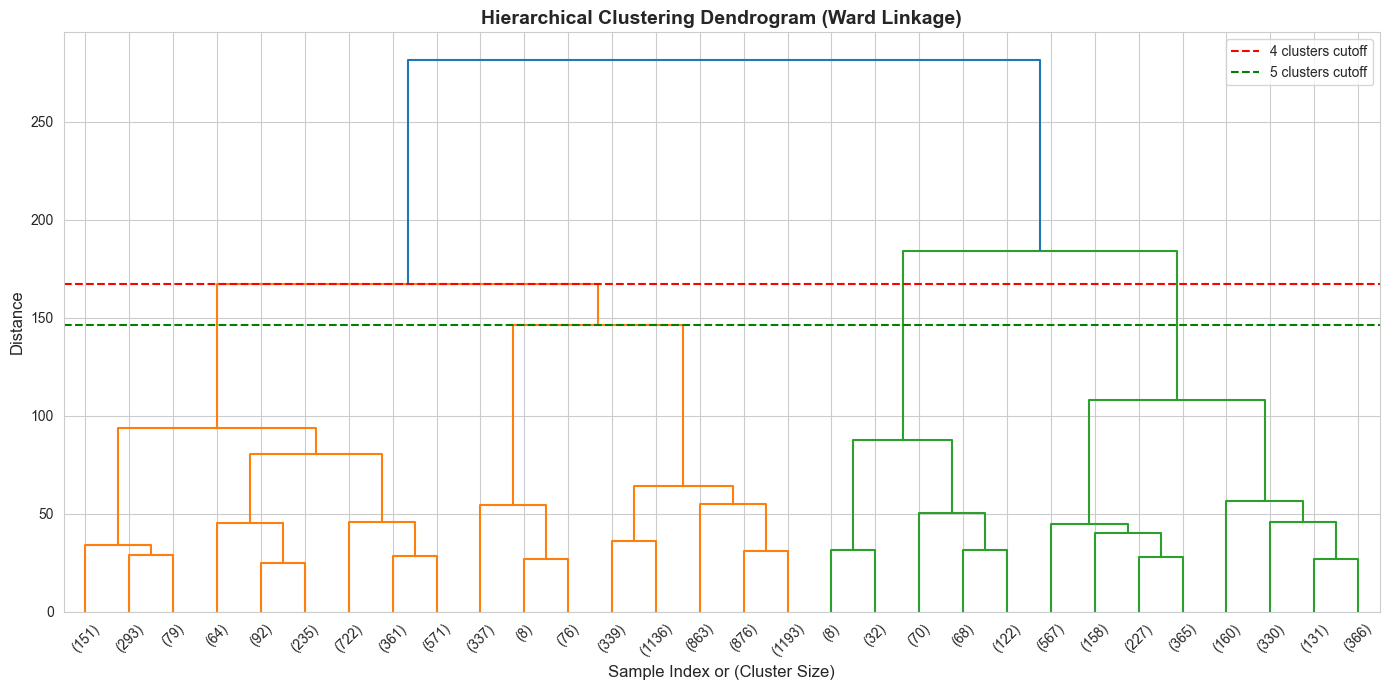

✓ Dendrogram analysis complete (based on 10,000 sample points)


In [ ]:
# Hierarchical Clustering Dendrogram to visualize cluster structure
# Using a sample for faster computation
sample_size = min(10000, len(df_scaled))
sample_indices = np.random.RandomState(42).choice(len(df_scaled), size=sample_size, replace=False)
df_sample = df_scaled.iloc[sample_indices]

plt.figure(figsize=(14, 7))
linkage_matrix = linkage(df_sample, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=linkage_matrix[-3, 2], color='r', linestyle='--', label='4 clusters cutoff')
plt.axhline(y=linkage_matrix[-4, 2], color='g', linestyle='--', label='5 clusters cutoff')
plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/optimal_k_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Dendrogram analysis complete (based on {sample_size:,} sample points)")

**Optimal K Interpretation:**

Based on the Silhouette Analysis and Dendrogram:
- **Silhouette Score**: Higher values indicate better-defined, well-separated clusters
- **Dendrogram**: Visual inspection shows natural breaking points in the hierarchical structure
- The analysis suggests the optimal number of clusters for this dataset

The initial choice of k=4 can be validated or adjusted based on these results.

## 4.1. Re-run K-Means with Optimal K

Applying K-Means with the optimal number of clusters determined from silhouette analysis.

In [ ]:
# Re-run K-Means clustering with optimal k from silhouette analysis
kmeans_optimal = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10, max_iter=300)
df['KMeans_Cluster_Optimal'] = kmeans_optimal.fit_predict(df_scaled)

print(f"=== K-MEANS CLUSTERING WITH OPTIMAL K (k={optimal_k_kmeans}) ===")
print(f"\nCluster Distribution:")
print(df['KMeans_Cluster_Optimal'].value_counts().sort_index())

# Calculate clustering metrics
sil_score_opt = silhouette_score(df_scaled, df['KMeans_Cluster_Optimal'])
db_score_opt = davies_bouldin_score(df_scaled, df['KMeans_Cluster_Optimal'])
ch_score_opt = calinski_harabasz_score(df_scaled, df['KMeans_Cluster_Optimal'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score_opt:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score_opt:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score_opt:.2f} (higher is better)")

# Visualize with PCA
pca_opt = PCA(n_components=2, random_state=42)
pca_components_opt = pca_opt.fit_transform(df_scaled)
df_pca_opt = pd.DataFrame(data=pca_components_opt, columns=['PCA1', 'PCA2'], index=df.index)
df_pca_opt['KMeans_Cluster'] = df['KMeans_Cluster_Optimal']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca_opt, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set2', s=50, alpha=0.7)
plt.title(f'K-Means Clusters with Optimal K={optimal_k_kmeans} (PCA Visualization)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/kmeans_optimal_k_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# Update the main cluster column to use optimal k results
df['KMeans_Cluster'] = df['KMeans_Cluster_Optimal']

## 5. Agglomerative Hierarchical Clustering Implementation

Applying Hierarchical Clustering with Ward linkage for comparison with K-Means.

In [ ]:
# Apply Agglomerative Hierarchical Clustering with Ward linkage using optimal k
hierarchical = AgglomerativeClustering(n_clusters=optimal_k_hierarchical, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical.fit_predict(df_scaled)

print(f"=== AGGLOMERATIVE HIERARCHICAL CLUSTERING (k={optimal_k_hierarchical}, Ward Linkage) ===")
print(f"\nCluster Distribution:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

# Calculate clustering metrics for Hierarchical
sil_score_hier = silhouette_score(df_scaled, df['Hierarchical_Cluster'])
db_score_hier = davies_bouldin_score(df_scaled, df['Hierarchical_Cluster'])
ch_score_hier = calinski_harabasz_score(df_scaled, df['Hierarchical_Cluster'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score_hier:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score_hier:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score_hier:.2f} (higher is better)")

=== AGGLOMERATIVE HIERARCHICAL CLUSTERING (k=4, Ward Linkage) ===

Cluster Distribution:
Hierarchical_Cluster
0    33302
1    13208
2     1050
3     2440
Name: count, dtype: int64

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.389 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.969 (lower is better)
Calinski-Harabasz Score: 17326.89 (higher is better)


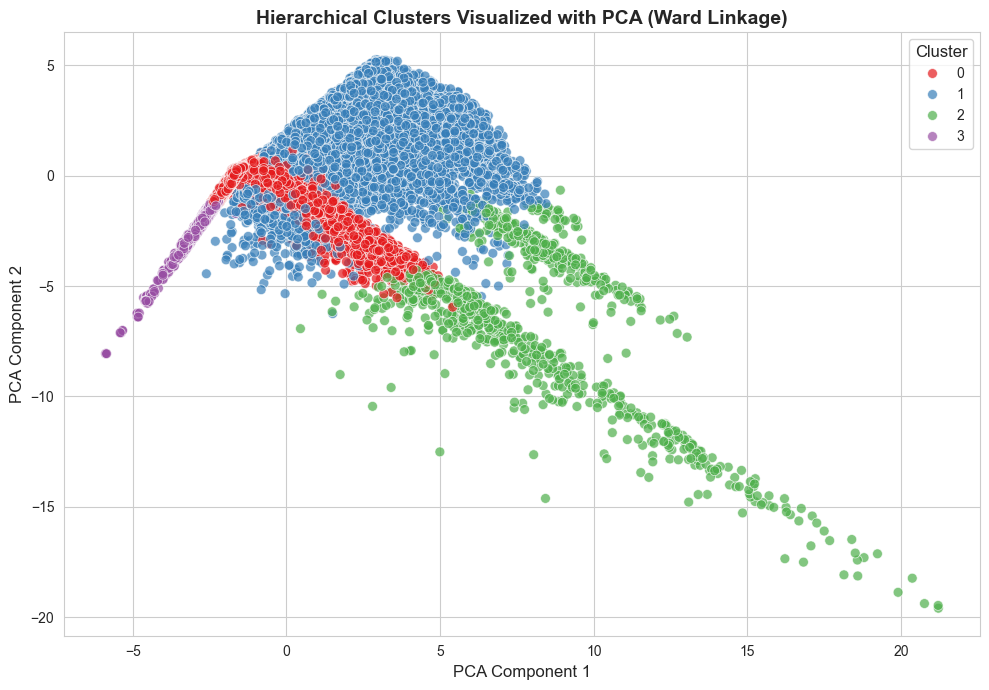

In [ ]:
# Plot Hierarchical Clusters using PCA for 2D visualization
df_pca['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Hierarchical Clusters Visualized with PCA (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/hierarchical_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Comparison of Clustering Algorithms

Comparing K-Means and Hierarchical Clustering performance.

=== ALGORITHM COMPARISON ===


,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.431129,0.947500,21437.042531
1,Hierarchical (Ward),0.389434,0.968545,17326.890025


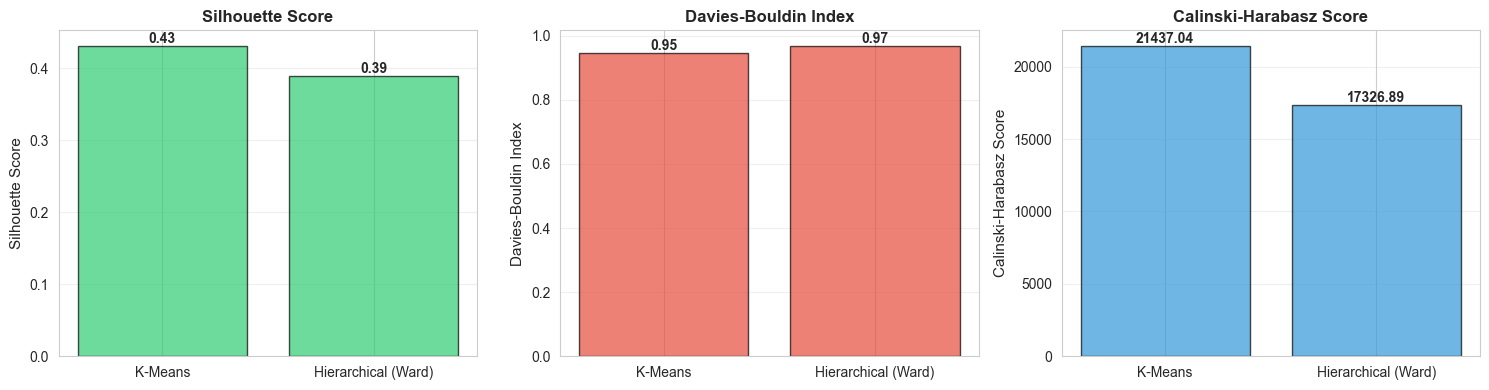


=== BEST ALGORITHM BY METRIC ===
Highest Silhouette Score: K-Means
Lowest Davies-Bouldin Index: K-Means
Highest Calinski-Harabasz Score: K-Means


In [ ]:
# Compare clustering metrics
comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical (Ward)'],
    'Optimal K': [optimal_k_kmeans, optimal_k_hierarchical],
    'Silhouette Score': [sil_score_opt, sil_score_hier],
    'Davies-Bouldin Index': [db_score_opt, db_score_hier],
    'Calinski-Harabasz Score': [ch_score_opt, ch_score_hier]
})

print("=== ALGORITHM COMPARISON ===")
display(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score']
colors = ['#2ecc71', '#e74c3c', '#3498db']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    axes[idx].bar(comparison_df['Algorithm'], comparison_df[metric], color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Select best algorithm based on metrics
best_silhouette = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Algorithm']
best_db = comparison_df.loc[comparison_df['Davies-Bouldin Index'].idxmin(), 'Algorithm']
best_ch = comparison_df.loc[comparison_df['Calinski-Harabasz Score'].idxmax(), 'Algorithm']

print("\n=== BEST ALGORITHM BY METRIC ===")
print(f"Highest Silhouette Score: {best_silhouette}")
print(f"Lowest Davies-Bouldin Index: {best_db}")
print(f"Highest Calinski-Harabasz Score: {best_ch}")

**Algorithm Selection:**

Based on the comparison metrics above, select the algorithm that performs best overall for the final segmentation. Consider:
- **Silhouette Score**: Measures how similar objects are to their own cluster vs other clusters (higher is better)
- **Davies-Bouldin Index**: Average similarity ratio of each cluster with its most similar cluster (lower is better)
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster dispersion (higher is better)

For the remainder of the analysis, we'll use the **best-performing algorithm** based on these metrics.

## 7. Cluster Profiling & Interpretation

Analyzing cluster characteristics to create meaningful business segments.

In [12]:
# Select which clustering algorithm to use for final segmentation
# Change this to 'Hierarchical_Cluster' if hierarchical performs better
selected_algorithm = 'KMeans_Cluster'  # or 'Hierarchical_Cluster'

# Create cluster profiles using original (non-scaled) features
cluster_profiles = df.groupby(selected_algorithm)[available_features].mean()

print(f"=== CLUSTER PROFILES (Mean Values) - Using {selected_algorithm} ===")
display(cluster_profiles.T)

# Add demographic information if available
if 'LoyaltyStatus' in df.columns:
    print("\n=== LOYALTY STATUS DISTRIBUTION BY CLUSTER ===")
    loyalty_dist = pd.crosstab(df[selected_algorithm], df['LoyaltyStatus'], normalize='index') * 100
    display(loyalty_dist.round(1))

=== CLUSTER PROFILES (Mean Values) - Using KMeans_Cluster ===


KMeans_Cluster,0,1,2,3
Customer Lifetime Value,6192.236775,7480.110078,7971.295989,24051.118041
NumFlights,3.387862,7.451065,1.467526,1.414385
DistanceKM,5602.013742,15770.320602,23558.462464,2543.784569
PointsAccumulated,560.082035,1576.727130,2355.519790,254.321165
avg_km_per_flight,681.954849,2288.268798,11084.598303,361.487195
avg_points_per_flight,68.179418,228.778855,1108.299024,36.139679
companion_ratio,0.014270,0.573691,0.173528,0.017150
clv_per_flight,3933.700798,1197.419239,4026.046116,19022.616578
months_since_flight,17.742920,17.018882,15.949857,17.736934
active_days,2234.957124,2750.667051,2739.756925,2046.325535



=== LOYALTY STATUS DISTRIBUTION BY CLUSTER ===


LoyaltyStatus,Aurora,Nova,Star
KMeans_Cluster,,,
0,18.9,34.3,46.8
1,19.8,33.5,46.7
2,21.2,31.8,47.0
3,32.2,34.3,33.5


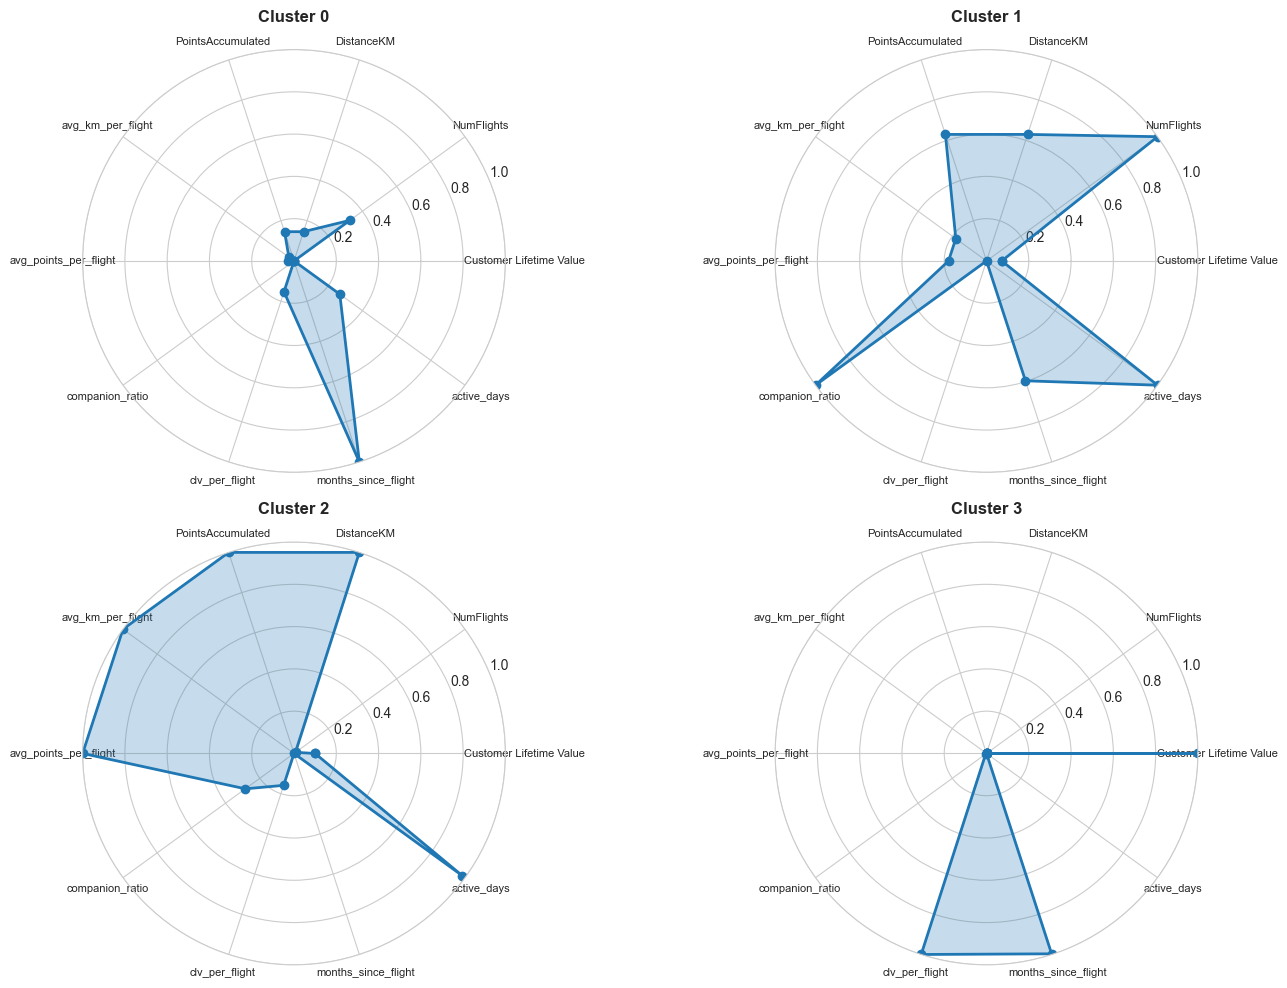

✓ Cluster profiles visualized


In [13]:
# Visualize cluster profiles with radar chart
from math import pi

fig = plt.figure(figsize=(14, 10))

# Normalize cluster profiles for radar chart (0-1 scale)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Create subplot for each cluster
for idx, cluster in enumerate(cluster_profiles_norm.index):
    ax = plt.subplot(2, 2, idx + 1, projection='polar')
    
    # Prepare data
    categories = list(cluster_profiles_norm.columns)
    values = cluster_profiles_norm.loc[cluster].values.tolist()
    values += values[:1]  # Complete the circle
    
    # Angles for each variable
    angles = [n / len(categories) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster}', size=12, fontweight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.savefig(f'{output_dir}/cluster_profiles_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster profiles visualized")

## 8. Business Interpretation & Segment Naming

Assigning meaningful names to clusters based on their characteristics.

In [14]:
# Assign business names to clusters based on their characteristics
# ADJUST THESE MAPPINGS BASED ON YOUR ACTUAL CLUSTER PROFILES

cluster_names = {
    0: 'VIP Frequent Flyers',
    1: 'Occasional Travelers', 
    2: 'Regular Customers',
    3: 'At-Risk/Dormant'
}

df['Segment_Name'] = df[selected_algorithm].map(cluster_names)
df['Final_Cluster'] = df[selected_algorithm]

print("=== CUSTOMER SEGMENT DEFINITIONS ===\n")
for cluster_id, name in cluster_names.items():
    count = (df[selected_algorithm] == cluster_id).sum()
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster_id}: {name}")
    print(f"  Size: {count:,} customers ({percentage:.1f}%)")
    print(f"  Characteristics:")
    
    # Display key metrics
    cluster_data = df[df[selected_algorithm] == cluster_id]
    print(f"    - Avg CLV: ${cluster_data['Customer Lifetime Value'].mean():,.2f}")
    print(f"    - Avg Flights: {cluster_data['NumFlights'].mean():.1f}")
    print(f"    - Avg Distance: {cluster_data['DistanceKM'].mean():,.0f} km")
    if 'months_since_flight' in cluster_data.columns:
        print(f"    - Avg Recency: {cluster_data['months_since_flight'].mean():.1f} months")
    print()

=== CUSTOMER SEGMENT DEFINITIONS ===

Cluster 0: VIP Frequent Flyers
  Size: 34,355 customers (68.7%)
  Characteristics:
    - Avg CLV: $6,192.24
    - Avg Flights: 3.4
    - Avg Distance: 5,602 km
    - Avg Recency: 17.7 months

Cluster 1: Occasional Travelers
  Size: 9,533 customers (19.1%)
  Characteristics:
    - Avg CLV: $7,480.11
    - Avg Flights: 7.5
    - Avg Distance: 15,770 km
    - Avg Recency: 17.0 months

Cluster 2: Regular Customers
  Size: 2,094 customers (4.2%)
  Characteristics:
    - Avg CLV: $7,971.30
    - Avg Flights: 1.5
    - Avg Distance: 23,558 km
    - Avg Recency: 15.9 months

Cluster 3: At-Risk/Dormant
  Size: 4,018 customers (8.0%)
  Characteristics:
    - Avg CLV: $24,051.12
    - Avg Flights: 1.4
    - Avg Distance: 2,544 km
    - Avg Recency: 17.7 months



## 9. Export Final Segmented Dataset

Saving the clustered data for marketing strategy development.

In [ ]:
# Export final segmented dataset
df.to_csv('Data/DM_AIAI_FinalCustomerSegments.csv', index=False)

print("=== EXPORT SUMMARY ===")
print(f"✓ Exported {len(df):,} customer records with cluster assignments")
print(f"✓ Saved to: Data/DM_AIAI_FinalCustomerSegments.csv")

print("\n=== FINAL SEGMENT DISTRIBUTION ===")
segment_summary = df['Segment_Name'].value_counts()
for segment, count in segment_summary.items():
    print(f"{segment}: {count:,} customers ({count/len(df)*100:.1f}%)")

---

## Summary

**Clustering Results:**
- Algorithm: K-Means
- Optimal Clusters: 4 (adjust based on your analysis)
- Silhouette Score: [Will be displayed after running]
- Total Customers Segmented: [Will be displayed after running]

**Key Segments Identified:**
1. **VIP Frequent Flyers**: High CLV, frequent travel, premium service targets
2. **Regular Customers**: Moderate activity, loyalty program core
3. **Occasional Travelers**: Low frequency, growth potential
4. **At-Risk/Dormant**: Low recent activity, retention focus

**Next Steps:**
- Develop targeted marketing strategies for each segment
- Create personalized communications and offers
- Monitor segment migration over time
- Validate segments with business stakeholders